In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()
# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 3

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

b = np.array([0,0.25,0.25,0.25,0.25,0.5,0.5,0.5])
m

array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  2., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  2., -1.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  2., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  2., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1.,  2., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1.,  2., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2.]])

In [3]:
d,u = np.linalg.eig(m)
k = np.max(d)/np.min(d)
dm = max(d)
# m = m/dm

In [4]:
np.linalg.det(m)



7.999999999999998

In [5]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([1.80411242e-16+6.93889390e-17j, 2.50000000e-01+5.13478149e-16j,
       2.50000000e-01-2.98372438e-16j, 2.50000000e-01-3.33066907e-16j,
       2.50000000e-01-6.66133815e-16j, 5.00000000e-01-6.10622664e-16j,
       5.00000000e-01+6.80011603e-16j, 5.00000000e-01+7.21644966e-16j])

In [6]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(j,k,l):
        return np.kron(j,np.kron(k,l))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I)),np.conj(Ub.T))
          +np.dot(np.dot(Ub,tensor(I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [7]:
d,u = np.linalg.eig(A)
d

array([ 1.07137160e+01+4.60313931e-30j,  5.17089365e+00+4.54046984e-31j,
        4.37778335e+00-1.58546536e-30j,  2.55258866e+00+3.93905099e-30j,
        7.69885428e-01+6.47252844e-32j,  4.68684258e-01+2.35468363e-30j,
        1.06162203e-01-7.20815494e-31j, -1.90838462e-16-1.22075630e-30j])

[0.52822308 0.40519007 0.48765494 0.56605484 0.25056377 0.60720049
 0.53942809 0.61184558 0.99554639 0.74489715 0.81785207 0.25282619
 0.41243963 0.11381233 0.76354501 0.12637757 0.54608607 0.65329402
 0.20654193 0.89865501 0.5440122  0.26823429 0.24008469 0.44891939
 0.56125941 0.05261654 0.02638421 0.06759133 0.32614957 0.39266204
 0.19674497 0.49752617 0.77267437 0.36766943 0.13459572 0.19071781
 0.32369167 0.16330848 0.97698898 0.77080536 0.9932332  0.01020086
 0.46480411 0.36827222 0.85136601 0.56377214 0.76375202 0.70418403
 0.51832791 0.95456412 0.07161198 0.87443302 0.80597287 0.3618098 ]


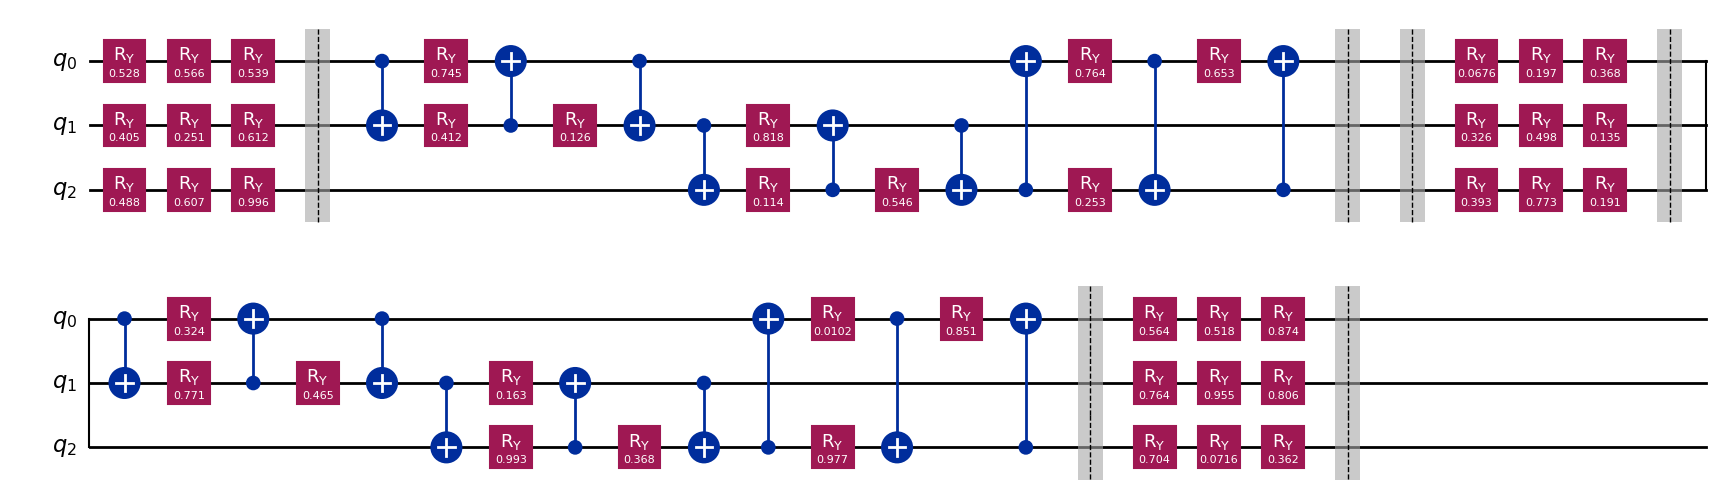

In [8]:

def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc

nb_qubits=3
depth=2
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)

# Parameters = np.array([random.random() for _ in range(0, nb_params)])
Parameters = np.array([0.52822308, 0.40519007, 0.48765494, 0.56605484, 0.25056377,
       0.60720049, 0.53942809, 0.61184558, 0.99554639, 0.74489715,
       0.81785207, 0.25282619, 0.41243963, 0.11381233, 0.76354501,
       0.12637757, 0.54608607, 0.65329402, 0.20654193, 0.89865501,
       0.5440122 , 0.26823429, 0.24008469, 0.44891939, 0.56125941,
       0.05261654, 0.02638421, 0.06759133, 0.32614957, 0.39266204,
       0.19674497, 0.49752617, 0.77267437, 0.36766943, 0.13459572,
       0.19071781, 0.32369167, 0.16330848, 0.97698898, 0.77080536,
       0.9932332 , 0.01020086, 0.46480411, 0.36827222, 0.85136601,
       0.56377214, 0.76375202, 0.70418403, 0.51832791, 0.95456412,
       0.07161198, 0.87443302, 0.80597287, 0.3618098 ])
print(Parameters)
ansatz(Parameters).draw("mpl")


In [9]:

U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
C_u5gate=u5gate.control()
C_u6gate=u6gate.control()
C_u7gate=u7gate.control()
C_u8gate=u8gate.control()
    

In [11]:

def circ(parameters):
    x=QuantumRegister(11)
    c=ClassicalRegister(8)
    circuit = QuantumCircuit(x,c)
    phi=parameters
    circuit=circuit.compose(ansatz(parameters),x[8:11])
    circuit.h(x[0:8]) 
    circuit.append(C_u1gate, [x[0],x[8],x[9],x[10]])    
    circuit.append(C_u2gate, [x[1],x[8],x[9],x[10]])    
    circuit.append(C_u3gate, [x[2],x[8],x[9],x[10]])    
    circuit.append(C_u4gate, [x[3],x[8],x[9],x[10]]) 
    circuit.append(C_u5gate, [x[4],x[8],x[9],x[10]])
    circuit.append(C_u6gate, [x[5],x[8],x[9],x[10]])    
    circuit.append(C_u7gate, [x[6],x[8],x[9],x[10]]) 
    circuit.append(C_u8gate, [x[7],x[8],x[9],x[10]])
    circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True, 
                   inverse = True, insert_barriers = False, name='qft')
    circuit.measure(x[0:8],c)       
    return circuit

/tmp/ipykernel_848858/8292215.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True,


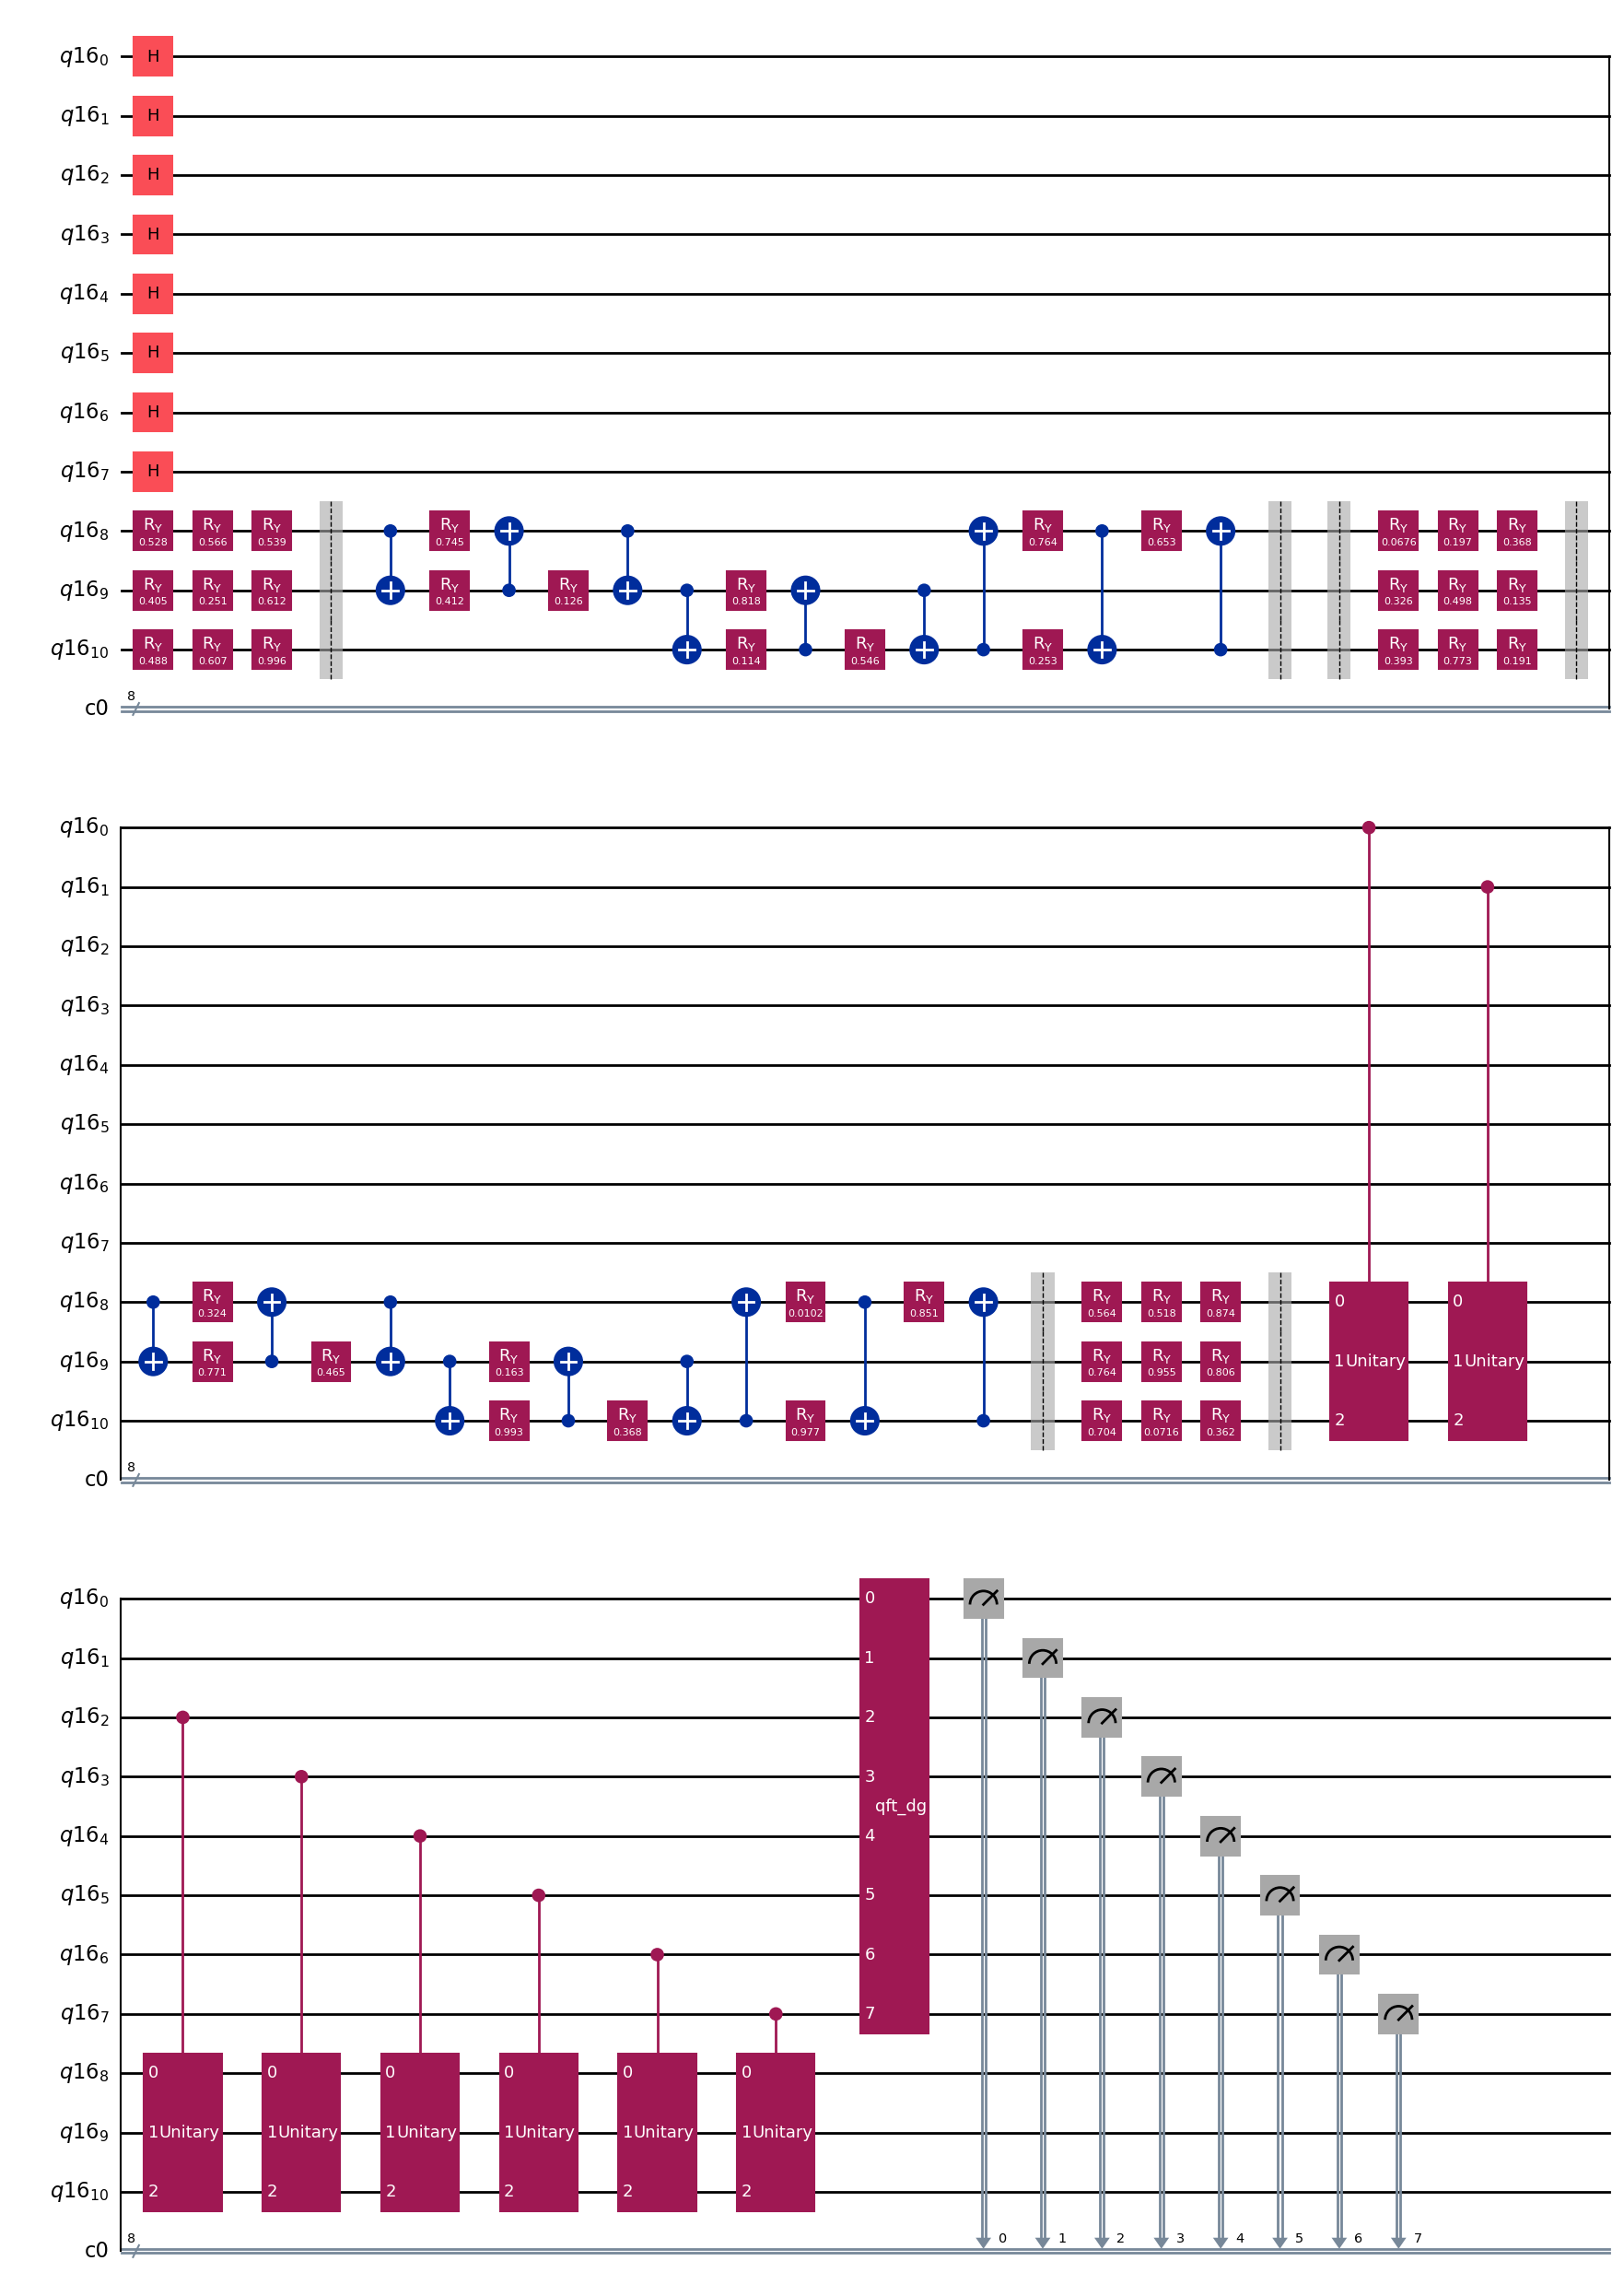

In [12]:
circ(Parameters).draw("mpl") 

In [13]:
shots = 100000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '00000000'not in result: 
        res = 1
    else:
        res = 1 - result['00000000']/shots
    return res
# cost(parameters)


In [14]:

def Optimizer(fun, x0, args=(), maxfev=None, 
              reset_interval=None, eps=None, callback=None, **_):
    
    x0 = np.asarray(x0)
    recycle_z0 = None
    niter = 0
    funcalls = 0

    while True:

        idx = niter % x0.size

        if reset_interval > 0:
            if niter % reset_interval == 0:
                recycle_z0 = None

        if recycle_z0 is None:
            z0 = fun(np.copy(x0), *args)
            funcalls += 1
        else:
            z0 = recycle_z0

        p = np.copy(x0)
        p[idx] = x0[idx] + np.pi / 2
        z1 = fun(p, *args)
        funcalls += 1

        p = np.copy(x0)
        p[idx] = x0[idx] - np.pi / 2
        z3 = fun(p, *args)
        funcalls += 1

        z2 = z1 + z3 - z0
        c = (z1 + z3) / 2
        a = np.sqrt((z0 - z2) ** 2 + (z1 - z3) ** 2) / 2
        b = np.arctan((z1 - z3) / ((z0 - z2) + 1e-32 * (z0 == z2))) + x0[idx]
        b += 0.5 * np.pi + 0.5 * np.pi * np.sign((z0 - z2) + eps * (z0 == z2))
        x0[idx] = b
        recycle_z0 = c - a
        if callback is not None:
            callback(np.copy(x0))
        if funcalls >= maxfev:
            break
        niter += 1
    # return OptimizeResult(fun=problabel0(np.copy(x0)), x=x0, nit=niter, 
    #                       nfev=funcalls, success=(niter > 1))

In [15]:
def save(Parameters):
    global Cost,Params
    Cost.append(cost(Parameters))
    Params.append(Parameters)
    print(cost(Parameters))
Cost = []
Params = []
Optimizer(cost, Parameters, args=(), maxfev = 4000, 
          reset_interval = 32, eps=1e-32, callback=save)
    

/tmp/ipykernel_2705292/8292215.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True,


0.98221
0.79192
0.77018
0.52483
0.49063999999999997
0.40925
0.40844
0.40092000000000005
0.39881999999999995
0.396
0.39527
0.38770000000000004
0.28635
0.24492999999999998
0.23941
0.24385
0.24033000000000004
0.23839999999999995
0.24170999999999998
0.24028000000000005
0.24068999999999996
0.24095999999999995
0.23838000000000004
0.23836000000000002
0.24055000000000004
0.23846999999999996
0.23948999999999998
0.21986000000000006
0.1966
0.17230999999999996
0.15200999999999998
0.15469999999999995
0.13880000000000003
0.13527
0.13239999999999996
0.1281
0.12446999999999997
0.12226000000000004
0.12265999999999999
0.09894000000000003
0.08189000000000002
0.08320000000000005
0.08247000000000004
0.07443999999999995
0.07452000000000003
0.04630999999999996
0.04478000000000004
0.043789999999999996
0.04218999999999995
0.04246000000000005
0.04171999999999998
0.041220000000000034
0.04054000000000002
0.041139999999999954
0.041590000000000016
0.04032999999999998
0.03915000000000002
0.03986000000000001
0.038510

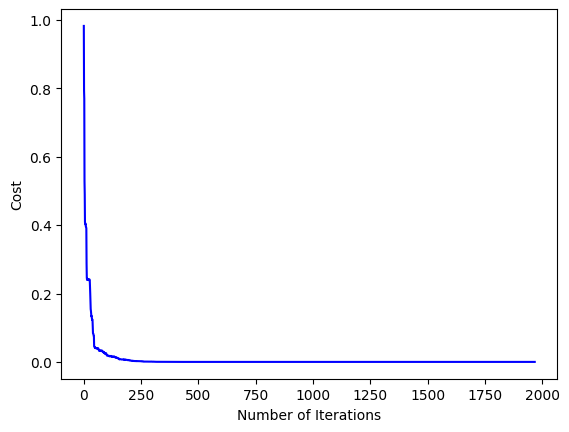

In [16]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [17]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [18]:
e = []
F =[ ]
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(state,x_exact)
    e.append(state - x_exact/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

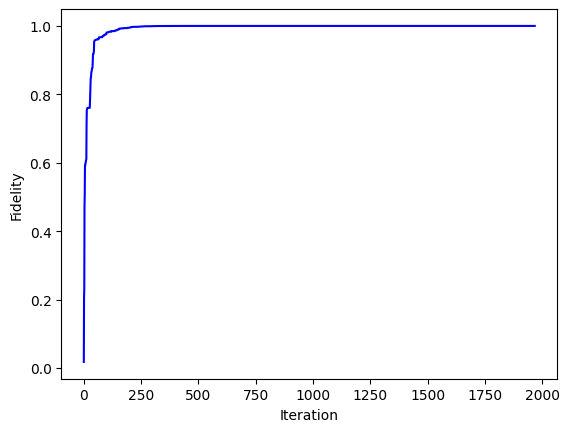

In [19]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [20]:
norm_e[np.argmax(F)]

0.001102066119794044

In [21]:
np.linalg.norm(np.real(e[np.argmax(F)]))

0.001102066119794044

Text(0.5, 0, 'Iteration')

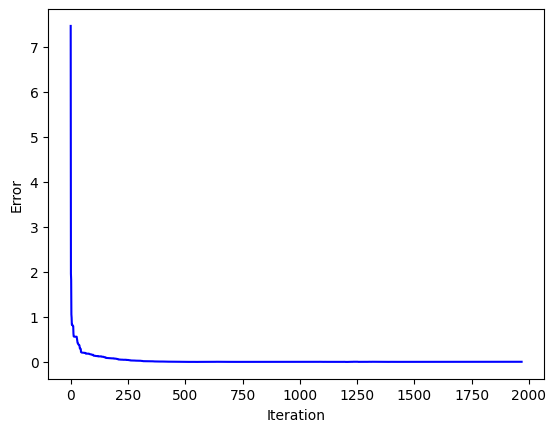

In [22]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [23]:
X_opt  = np.array(Statevector(ansatz(Params[np.argmax(F)])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [24]:
abs(np.array(e[-1]))

array([5.92521851e-05, 7.74018616e-04, 2.37833314e-03, 1.66039960e-04,
       1.85452067e-03, 8.66564146e-04, 2.56540744e-04, 2.78156940e-03])

In [26]:
print(F)

[0.017610691862125764, 0.20654224152319586, 0.23039711885242936, 0.47288226982475834, 0.5077644873772562, 0.5912910932029176, 0.5912867127916895, 0.5984770764244478, 0.5988869335484219, 0.6053912096066912, 0.6072091114384068, 0.6106611405974272, 0.713097681972159, 0.7540375197566334, 0.7581628747803013, 0.7581720634043322, 0.7596340530412318, 0.7604260550610691, 0.7604260550610691, 0.7604260550610691, 0.7604260550610691, 0.7604260550610691, 0.7604260550610691, 0.7604260550610691, 0.7604260550610691, 0.7604260550610691, 0.7604260550610691, 0.7799267837604393, 0.8022257312955003, 0.8290654210924391, 0.8472337400073243, 0.8483990673530144, 0.8593901181450391, 0.8659069986845833, 0.8666407680033779, 0.8708750664827356, 0.8760894176260909, 0.8763451217556263, 0.878594365104175, 0.9014012458367767, 0.916351383719746, 0.9173606162084664, 0.917365626577979, 0.9231114681398047, 0.9244485024504167, 0.9536794799065138, 0.9547416876493385, 0.9571311448860522, 0.9581420394001088, 0.9584182045558504

In [14]:
tqc = pm.run(circ(Parameters))
tqc.depth()

/tmp/ipykernel_848858/8292215.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True,


856

In [17]:
pm=generate_preset_pass_manager(basis_gates=['cx','sx','rz','x'],optimization_level=2)
circ1=pm.run(circ(Parameters))
circ1.depth()

/tmp/ipykernel_848858/8292215.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True,


1386